In [9]:
import numpy as np
import ast
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

'[Errno 11001] getaddrinfo failed' thrown while requesting HEAD https://huggingface.co/datasets/lukebarousse/data_jobs/resolve/ed776e5a0a8c40ea9d5efbd800772ae52e140f3e/data_jobs.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since lukebarousse/data_jobs couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at C:\Users\PC\.cache\huggingface\datasets\lukebarousse___data_jobs\default\0.0.0\ed776e5a0a8c40ea9d5efbd800772ae52e140f3e (last modified on Thu Aug 27 21:52:43 2026).


In [10]:
df_usa = df[
    (df['job_title_short'] == 'Data Analyst')
    & (df['job_country'] == 'United States')
]

df_DA_USA = (
    df_usa[['salary_year_avg', 'job_skills']]
    .dropna(subset=['salary_year_avg'])
    .explode('job_skills')
)

df_DA_USA

,salary_year_avg,job_skills
109,89000.0,python
109,89000.0,r
109,89000.0,alteryx
109,89000.0,tableau
180,90250.0,excel
...,...,...
784882,87500.0,sql
784882,87500.0,vba
784882,87500.0,tableau
784882,87500.0,excel


In [19]:
df_DA_USA_group=df_DA_USA.groupby('job_skills')['salary_year_avg'].agg(['count', 'median'])
df_DA_USA_top_pay=df_DA_USA_group.sort_values(by= 'median', ascending=False).head(10)
df_DA_USA_skills =df_DA_USA_group.sort_values(by='count', ascending= False).head(10).sort_values(by= 'median', ascending=False)

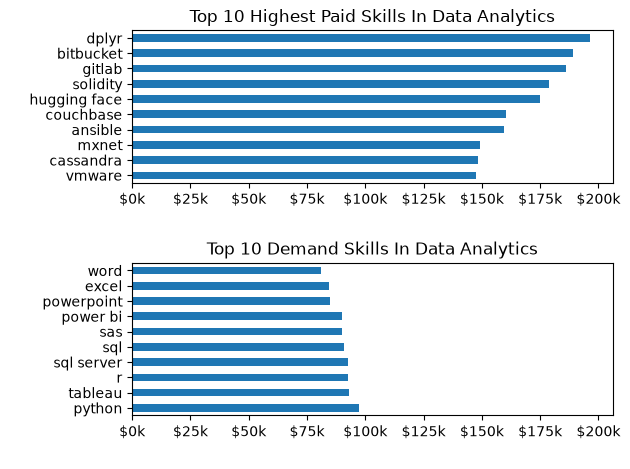

In [27]:
fig, ax= plt.subplots(2,1)
df_DA_USA_top_pay.plot(kind='barh', y='median', ax= ax[0], legend= False)
ax[0].invert_yaxis()
ax[0].set_title('Top 10 Highest Paid Skills In Data Analytics')
ax[0].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[0].set_xlabel(' ')
ax[0].set_ylabel(' ')

df_DA_USA_skills.plot(kind='barh', y='median', ax= ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim())
ax[1].set_title('Top 10 Demand Skills In Data Analytics')
ax[1].xaxis.set_major_formatter(lambda x, pos: f'${int(x/1000)}k')
ax[1].set_xlabel(' ')
ax[1].set_ylabel(' ')

fig.tight_layout()

<class 'pandas.DataFrame'>
